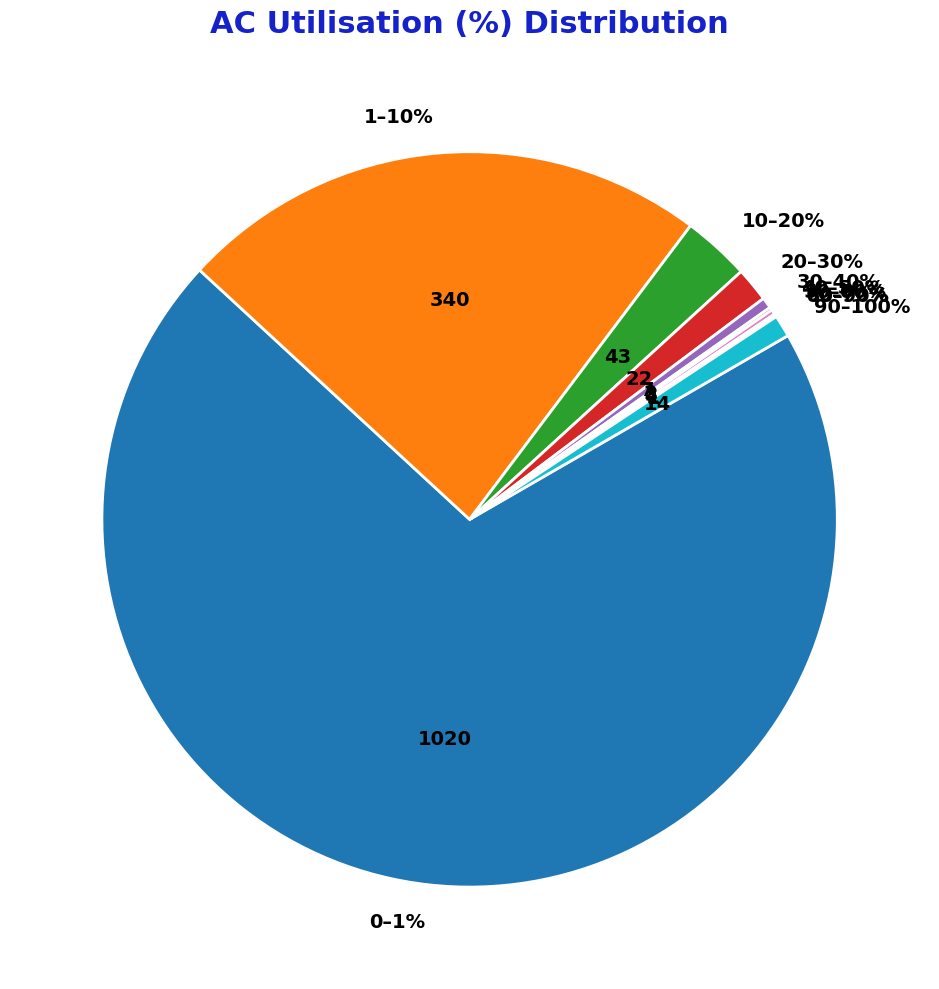

C:\Users\HTL_Sanmathi\AppData\Local\Temp\ipykernel_25176\2640889820.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['70-80%', '60-70%', '0-10%', '90-100%', '70-80%', ..., '80-90%', '70-80%', '90-100%', '80-90%', '60-70%']
Length: 1453
Categories (10, object): ['0-10%' < '10-20%' < '20-30%' < '30-40%' ... '60-70%' < '70-80%' < '80-90%' < '90-100%']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  df_plot.loc[:, 'bin'] = pd.cut(df_plot[metric], bins=bins, labels=labels, right=True, include_lowest=True)


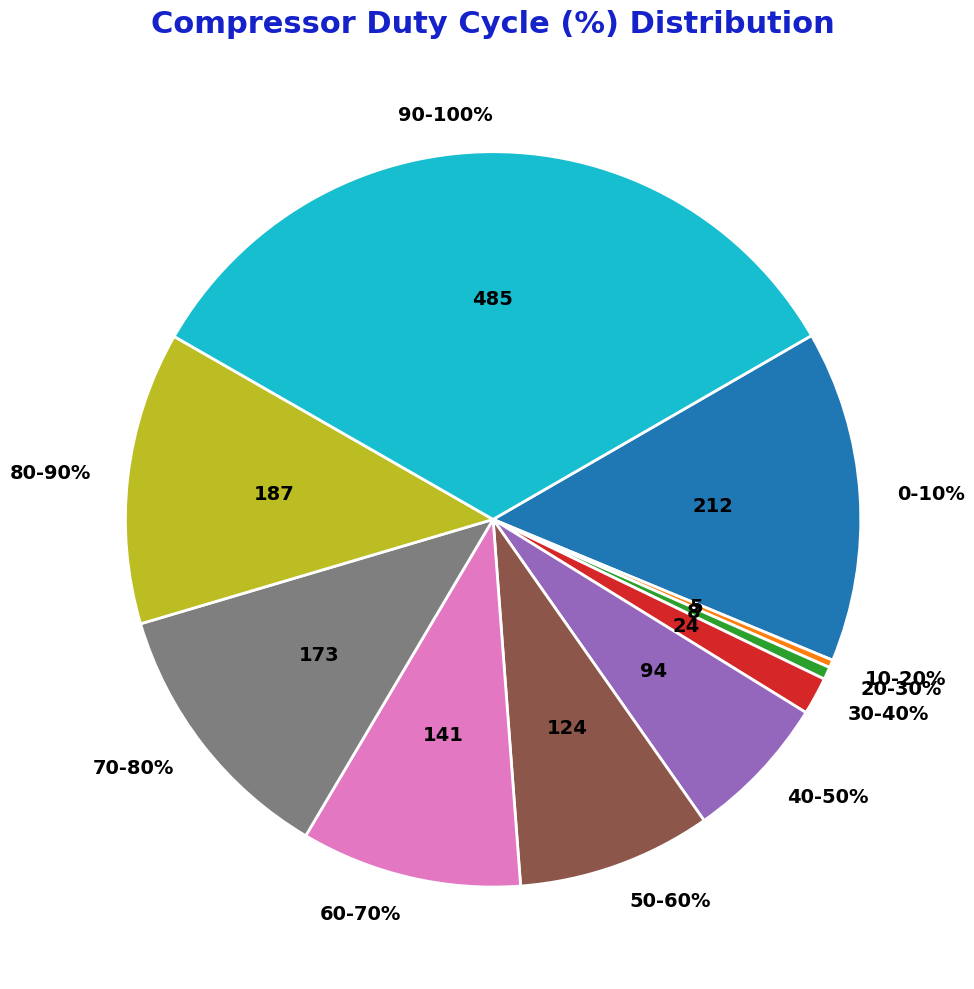

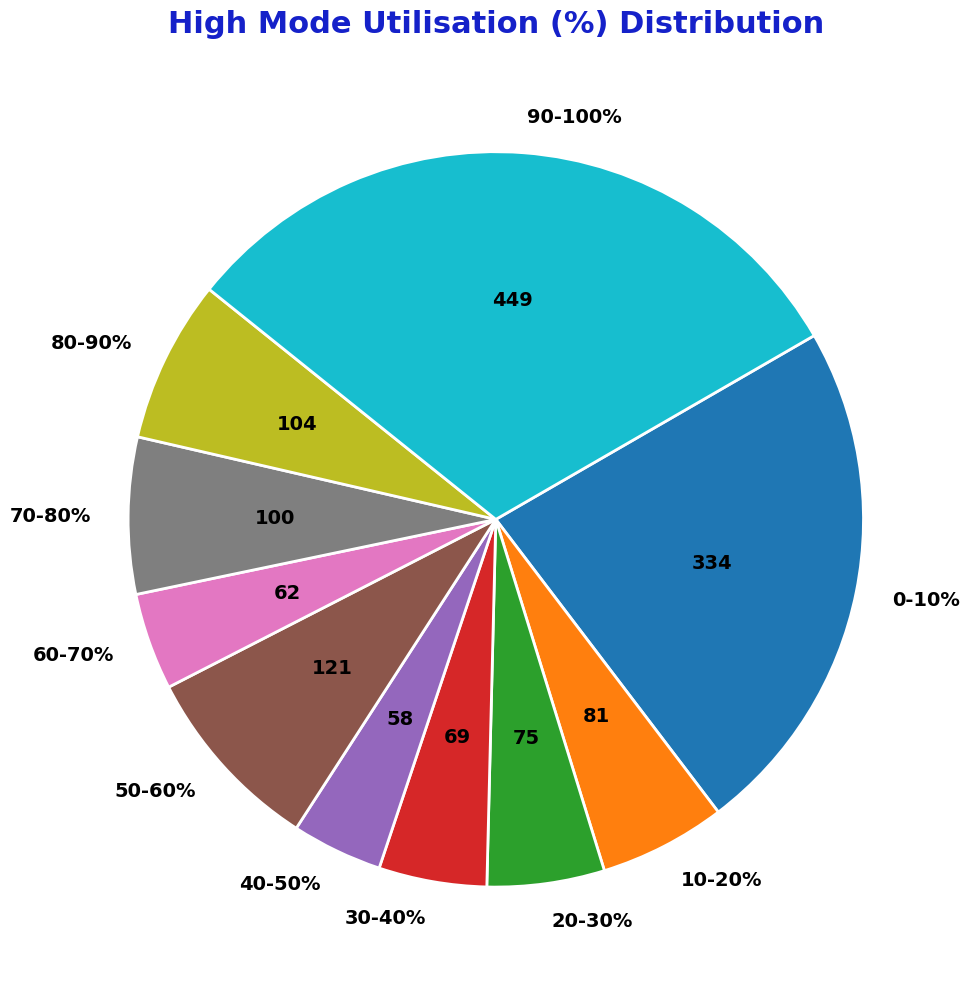

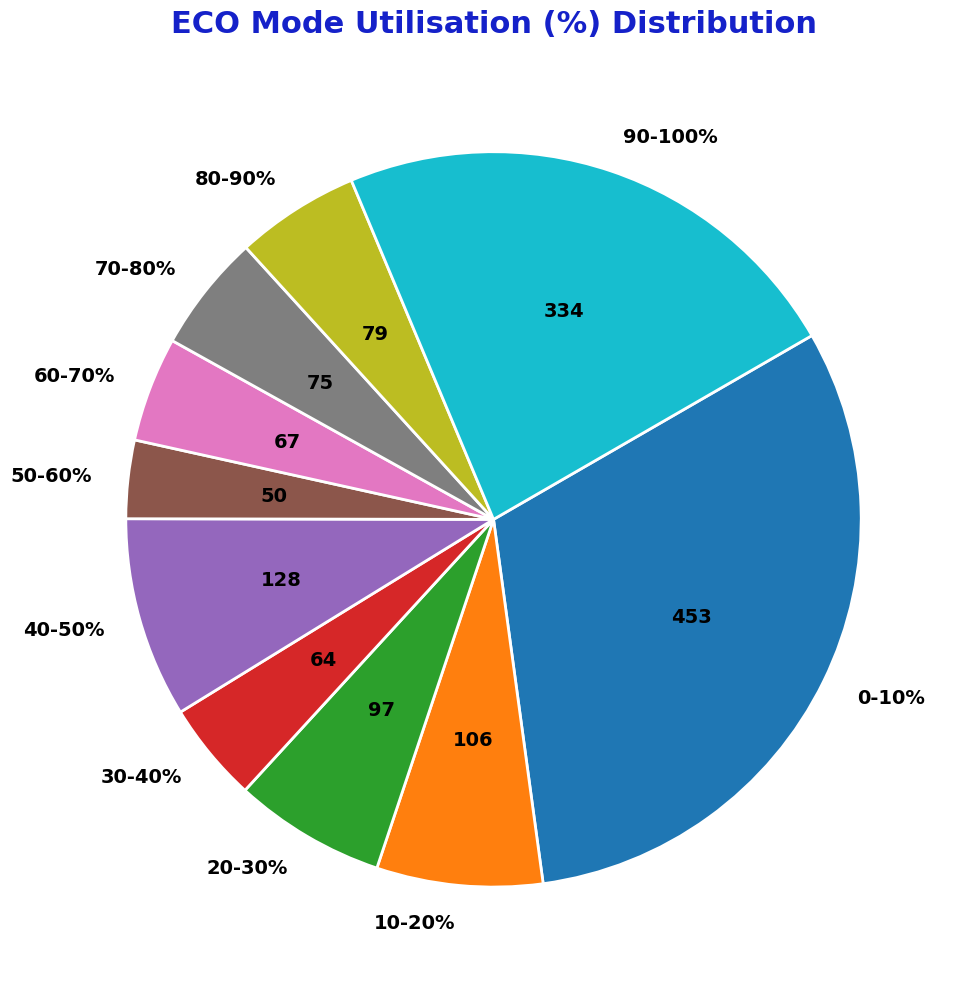

In [1]:
# AC Utilization flow chart code 


import pandas as pd
import matplotlib.pyplot as plt
import os

# === Custom bin logic ===
def custom_bins(metric_name):
    if metric_name == 'AC Utilisation (%)':
        bins = [0, 1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
        labels = ['0–1%', '1–10%', '10–20%', '20–30%', '30–40%', '40–50%',
                  '50–60%', '60–70%', '70–80%', '80–90%', '90–100%']
    else:
        bins = list(range(0, 110, 10))
        labels = [f"{i}-{i+10}%" for i in bins[:-1]]
    return bins, labels

# === Step 1: Load summary file ===
# Note: Ensure this file path is correct on your system
summary_file = r"C:\Users\HTL_Sanmathi\Downloads\AC_Dec_G45_Summary\G45_Single_AC_Summarization\G45_DEC_AC_Summary_Generation.csv"
df = pd.read_csv(summary_file)


# === Step 3: Remove summary row from plotting data ===
df_plot = df[df['VIN'] != 'VIN_COUNT_SUMMARY'].copy()

# === Step 4: Define metrics and titles ===
metrics = {
    'AC Utilisation (%)': 'AC Utilisation (%) Distribution',
    'Overall Compressor Duty Cycle (%)': 'Compressor Duty Cycle (%) Distribution',
    'AC Utilisation in High Mode (%)': 'High Mode Utilisation (%) Distribution',
    'AC Utilisation in ECO Mode (%)': 'ECO Mode Utilisation (%) Distribution'
}

# === Step 6: Plot each metric as pie chart ===
for metric, title in metrics.items():
    plt.figure(figsize=(10, 10))

    # Fill missing values safely
    df_plot.loc[:, metric] = df_plot[metric].fillna(0)

    # Apply bin logic
    bins, labels = custom_bins(metric)
    if len(labels) != len(bins) - 1:
        print(f"⚠️ Bin mismatch for {metric}: {len(bins)} bins, {len(labels)} labels")
        continue

    df_plot.loc[:, 'bin'] = pd.cut(df_plot[metric], bins=bins, labels=labels, right=True, include_lowest=True)

    # Count vehicles per bin
    bin_counts = df_plot['bin'].value_counts().sort_index()

    # === FIX: Filter out bins that have a count of 0 ===
    bin_counts = bin_counts[bin_counts > 0]

    # Check if there is data left to plot
    if bin_counts.empty:
        print(f"Skipping {metric} because all counts are zero.")
        plt.close()
        continue

    # Plot pie chart with VIN counts as labels
    plt.pie(
        bin_counts,
        labels=bin_counts.index,
        autopct=lambda pct: f"{int(round(pct * sum(bin_counts) / 100))}",
        startangle=30,
        counterclock=False,
        textprops={'fontsize': 14, 'fontweight': 'bold'},
        wedgeprops={'linewidth': 2, 'edgecolor': '#ffffff'}
    )

    # Chart styling
    plt.title(title, fontsize=22, fontweight='bold', color="#1521C9", pad=20)
    plt.tight_layout()
    plt.show()


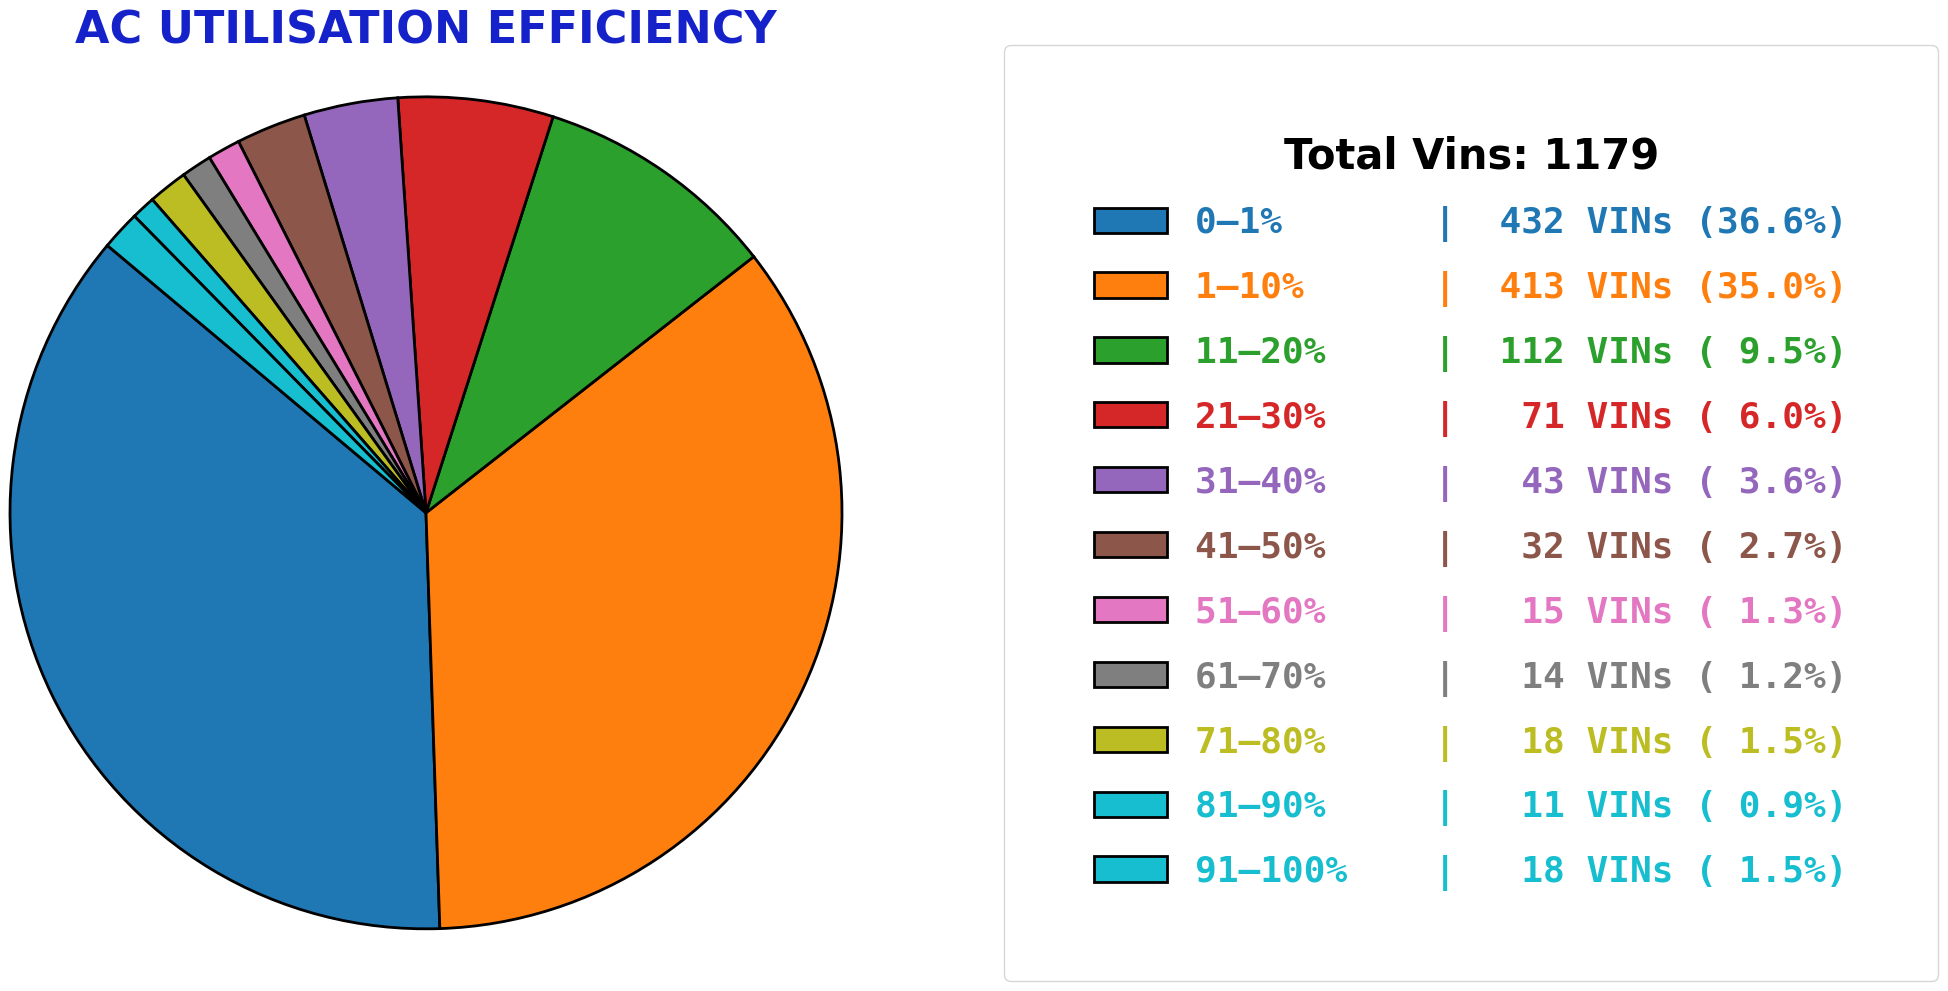

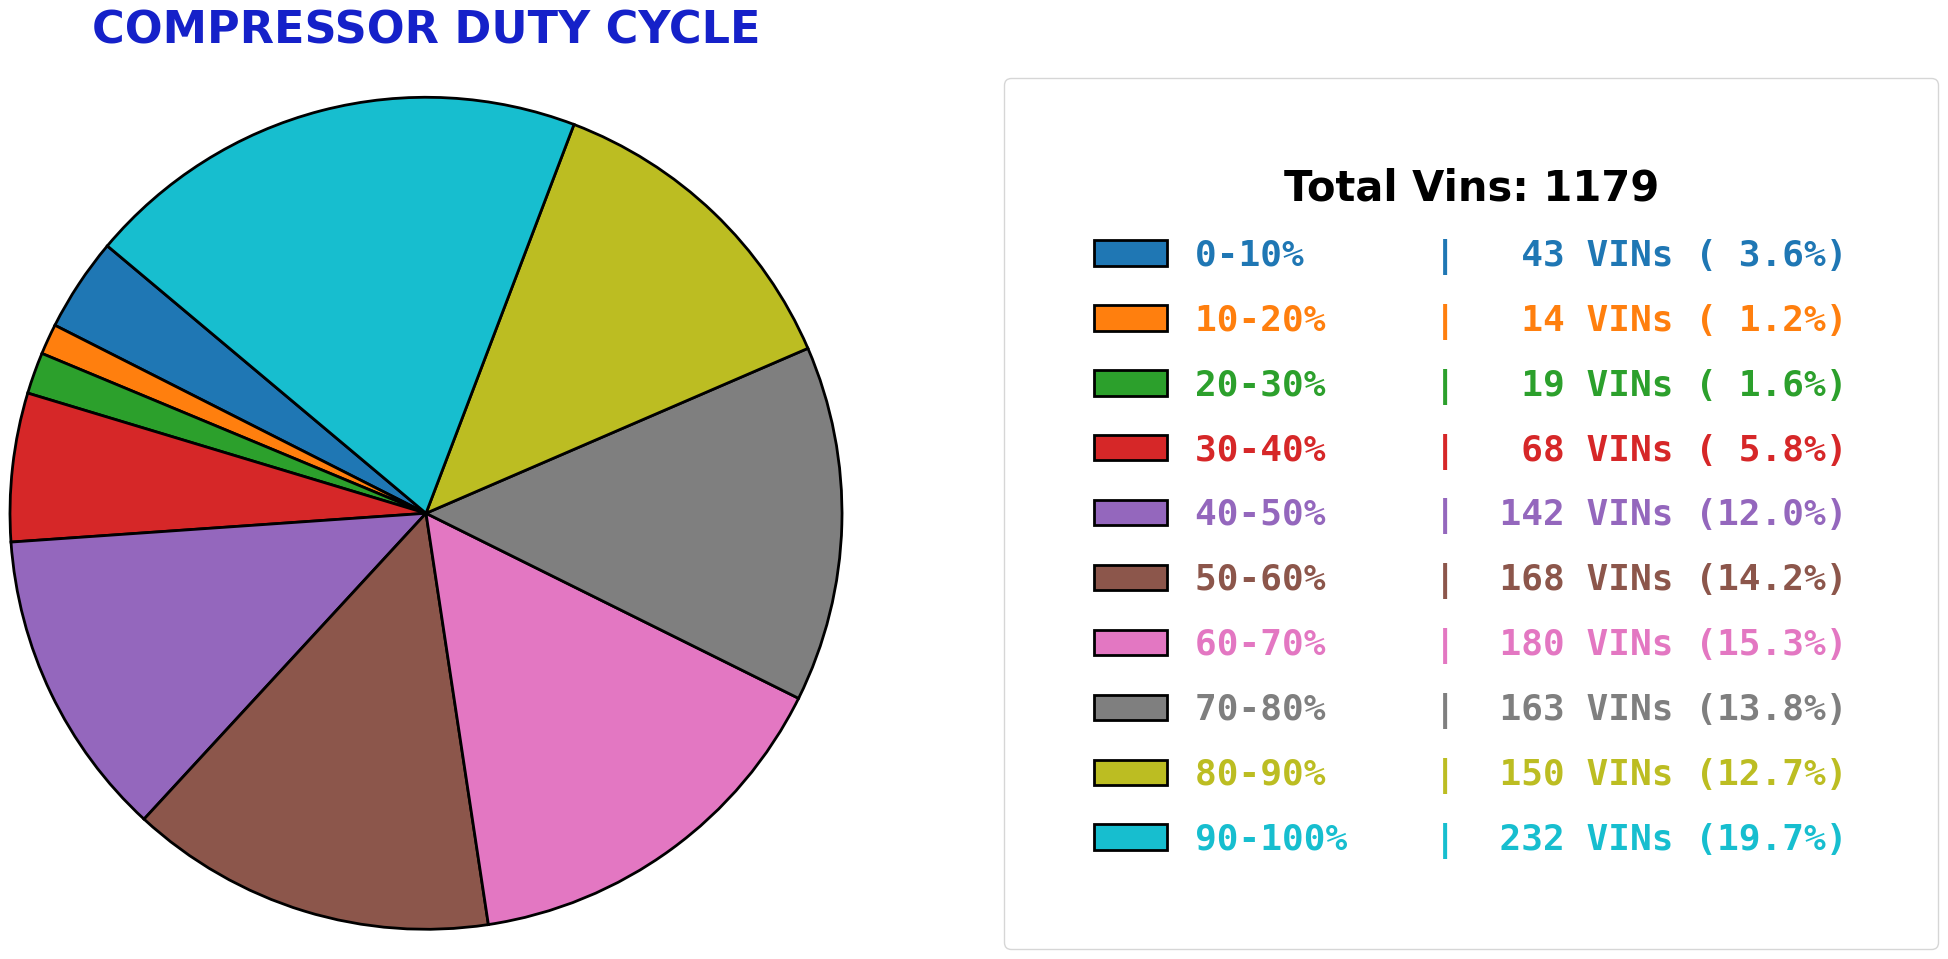

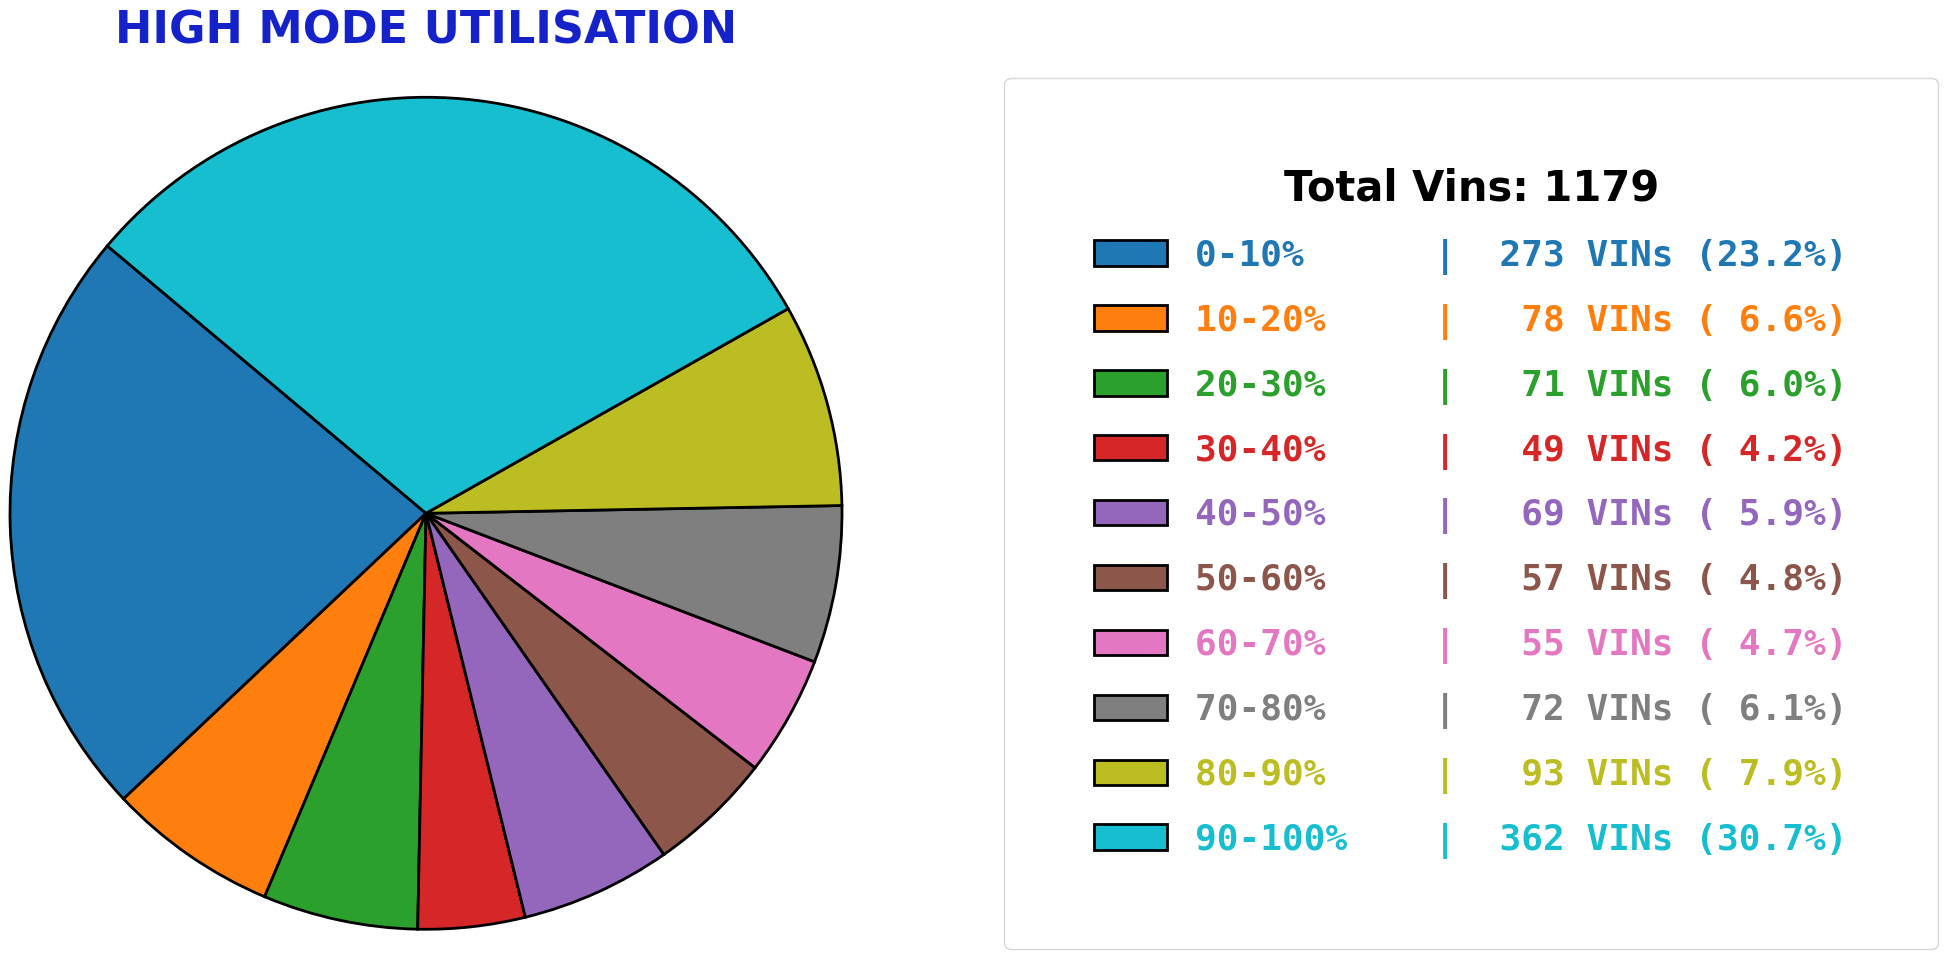

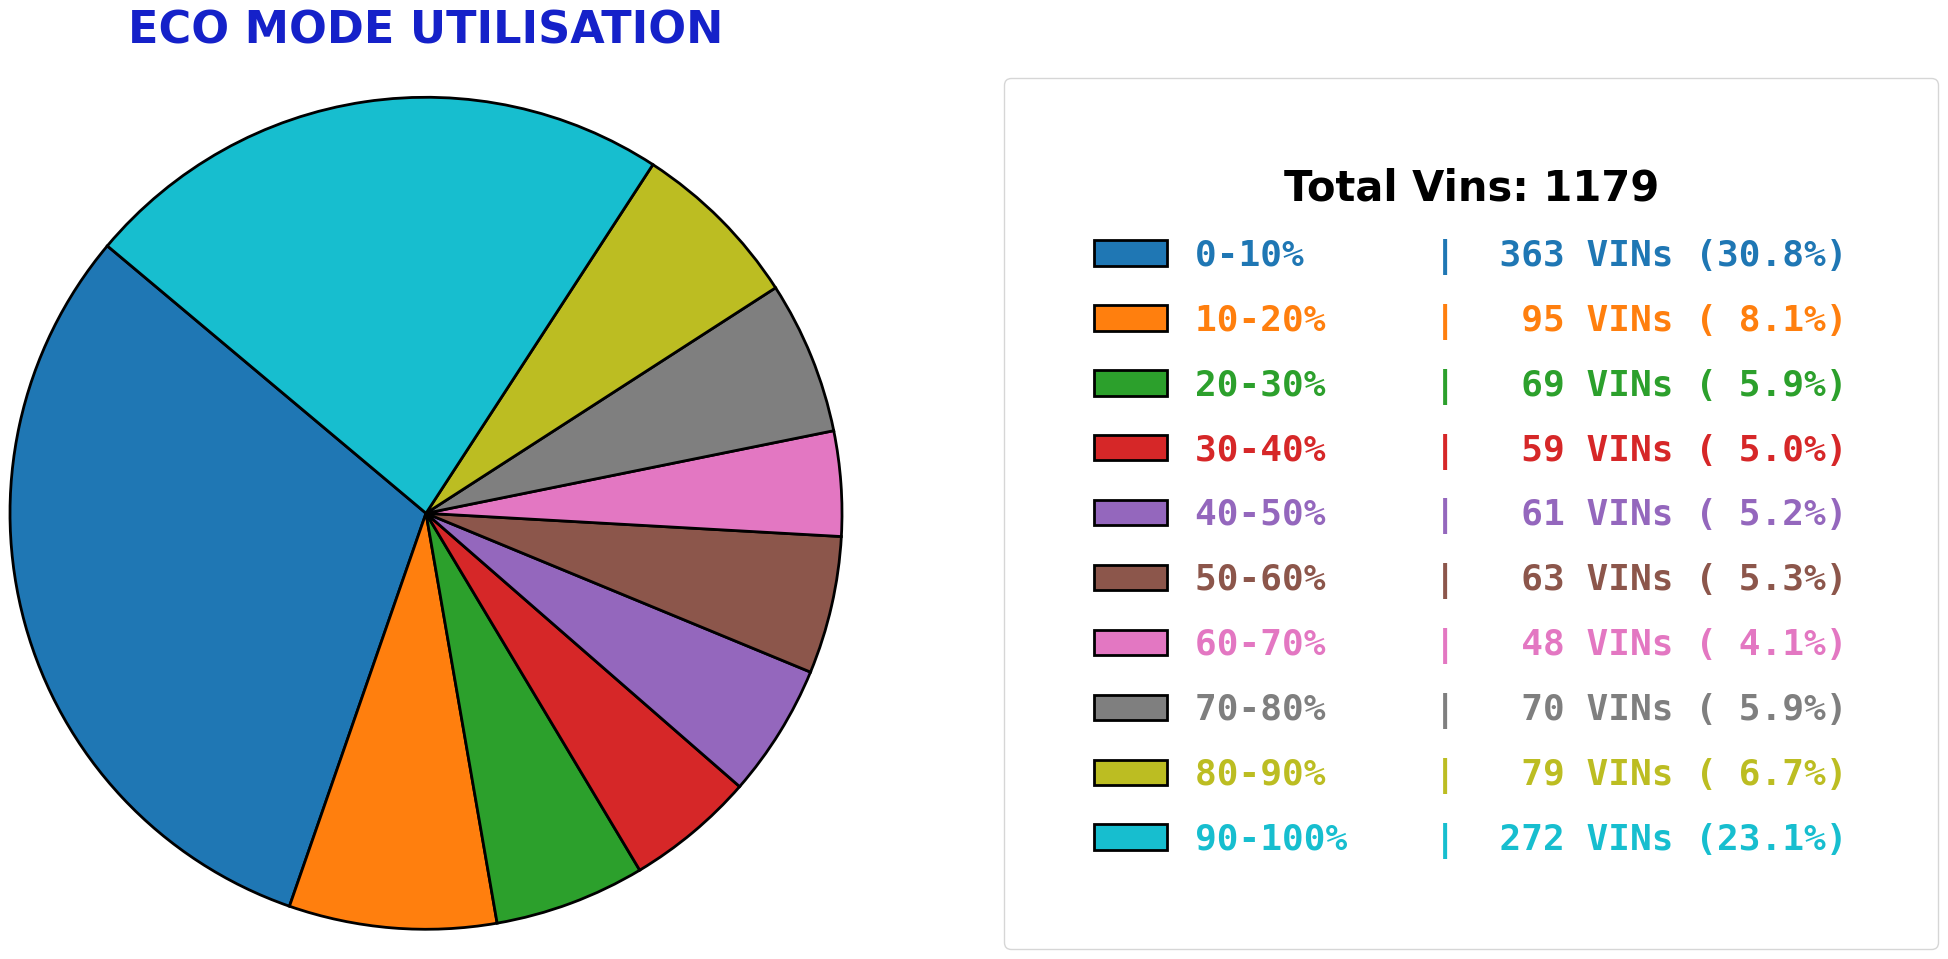

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1. Custom bin logic ===
def custom_bins(metric_name):
    if metric_name == 'AC Utilisation (%)':
        bins = [0, 1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
        labels = ['0–1%', '1–10%', '11–20%', '21–30%', '31–40%', '41–50%',
                  '51–60%', '61–70%', '71–80%', '81–90%', '91–100%']
    else:
        bins = list(range(0, 110, 10))
        labels = [f"{i}-{i+10}%" for i in bins[:-1]]
    return bins, labels

# === 2. Load Data ===
summary_file = r"C:\Users\HTL_Sanmathi\Downloads\AC_Dec_Boss_Trip_Summary\BOss_AC_Single_Summary_Generation\G45_DEC_AC_Summary_Generation.csv"
try:
    df = pd.read_csv(summary_file)
    df_plot = df[df['VIN'] != 'VIN_COUNT_SUMMARY'].copy()
except Exception as e:
    print(f"❌ Error: {e}")
    exit()

metrics = {
    'AC Utilisation (%)': 'AC UTILISATION EFFICIENCY',
    'Overall Compressor Duty Cycle (%)': 'COMPRESSOR DUTY CYCLE',
    'AC Utilisation in High Mode (%)': 'HIGH MODE UTILISATION',
    'AC Utilisation in ECO Mode (%)': 'ECO MODE UTILISATION'
}# === 3. Plotting: MAX Legend and MAX Chart Size ===
for metric, title in metrics.items():
    if metric not in df_plot.columns: continue

    df_plot[metric] = pd.to_numeric(df_plot[metric], errors='coerce').fillna(0)
    bins, labels = custom_bins(metric)
    df_plot['bin'] = pd.cut(df_plot[metric], bins=bins, labels=labels, right=True, include_lowest=True)
    
    bin_counts = df_plot['bin'].value_counts().sort_index()
    bin_counts = bin_counts[bin_counts > 0]
    if bin_counts.empty: continue

    total_vins = bin_counts.sum()
    
    # Large 16:9 ratio for PPT slides
    fig, ax = plt.subplots(figsize=(18, 10), facecolor="white")
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(bin_counts)))

    # Radius 1.3 pushes the pie to the vertical limits
    wedges, _ = ax.pie(
        bin_counts, 
        startangle=140,
        colors=colors,
        radius=1.3, 
        wedgeprops={'edgecolor': 'black', 'linewidth': 2},
        shadow=False
    )

    legend_labels = [f'{l:<10} | {v:>4} VINs ({(v/total_vins*100):>4.1f}%)' 
                     for l, v in zip(bin_counts.index, bin_counts.values)]
    
    # === HUGE LEGEND SECTION ===
    leg = ax.legend(
        wedges, 
        legend_labels,
        title=f"Total Vins: {total_vins}",
        title_fontproperties={'weight': 'bold', 'size': 30}, # EXTRA LARGE TITLE
        loc="center left",
        bbox_to_anchor=(1.2, 0.5), # Positioned to the right
        prop={'family': 'monospace', 'weight': 'bold', 'size': 26}, # EXTRA LARGE TEXT
        frameon=True,
        borderpad=2.5, # Massive padding inside the box
        labelspacing=0.8 # Massive gap between legend lines
    )

    # Apply bold colors to the legend text
    for i, text in enumerate(leg.get_texts()):
        text.set_color(colors[i])

    # HUGE TITLE
    plt.title(title, fontsize=32, fontweight='bold', color="#1521C9", pad=50)
    
    # Force the layout to stretch - No more gaps
    # right=0.65 makes the pie stay left, leaving huge room for the huge legend
    plt.subplots_adjust(left=0.05, right=0.65, top=0.85, bottom=0.05)
    
    plt.show()


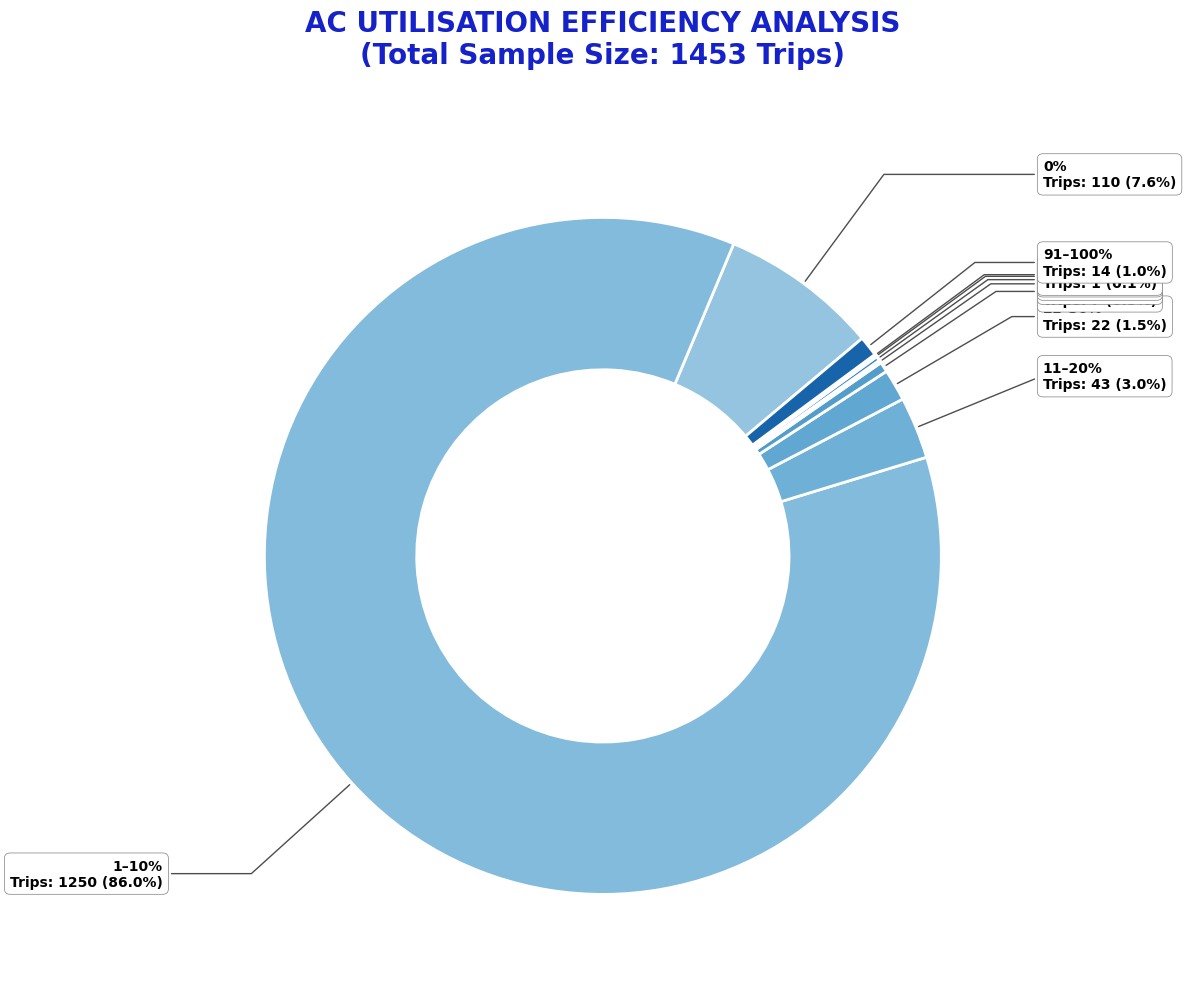

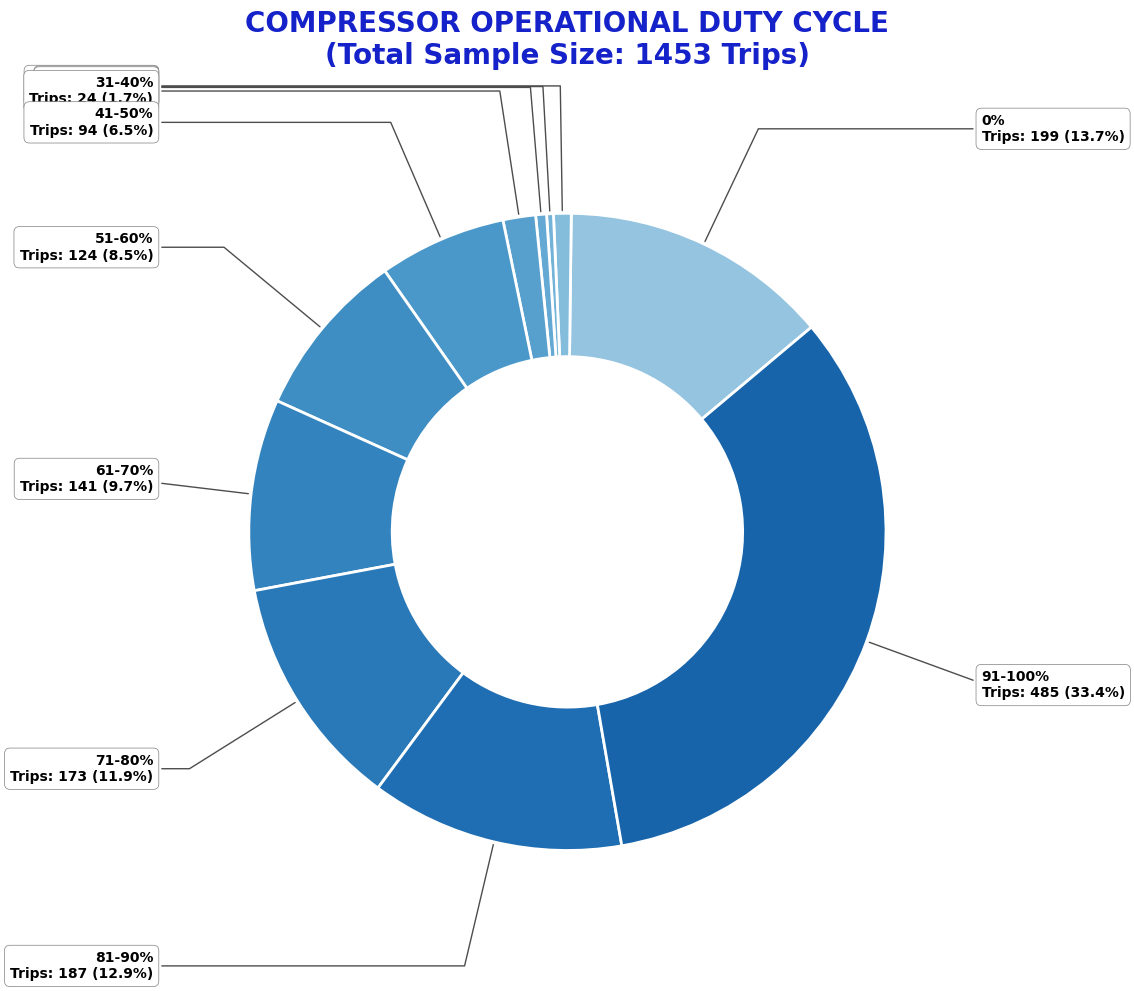

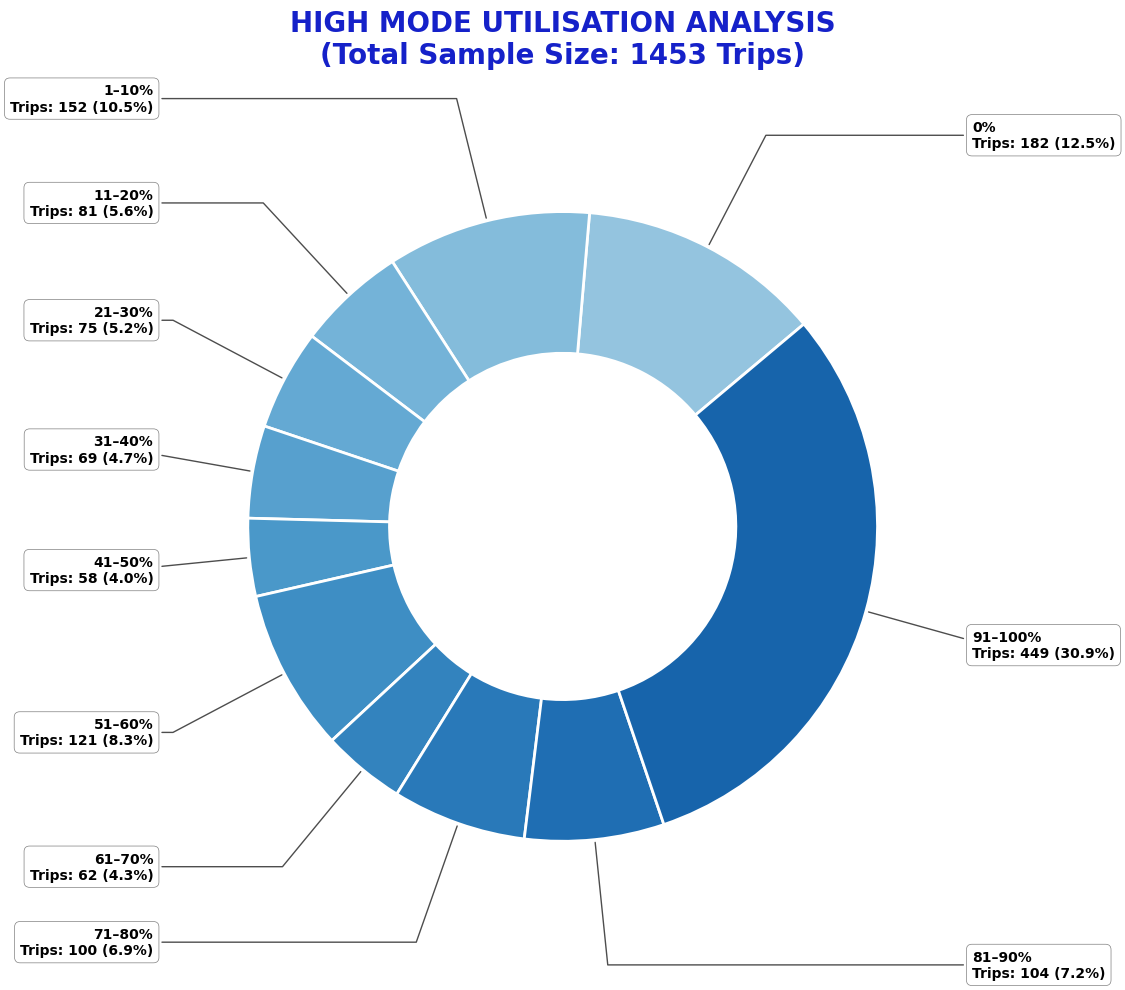

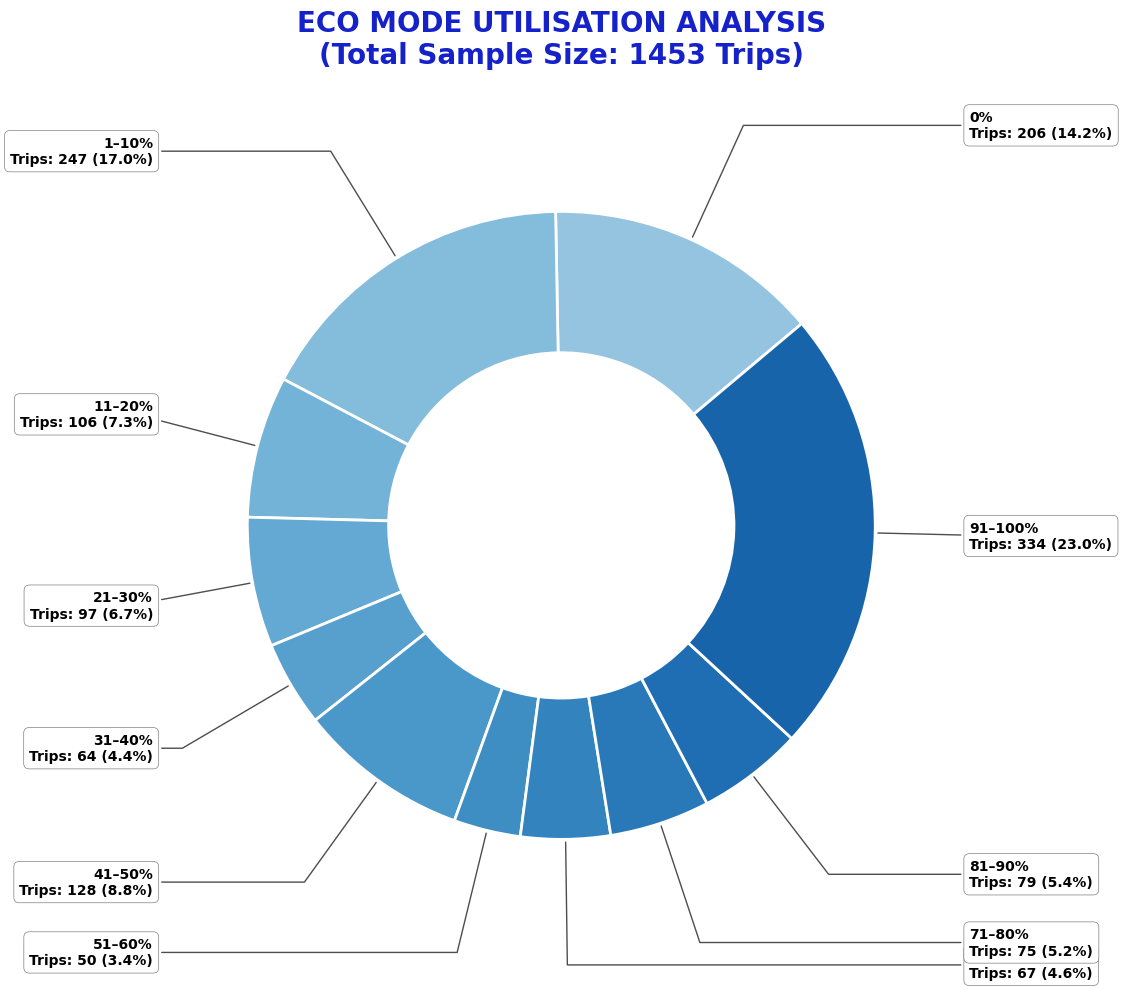

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1. Fixed Custom Bin Logic ===
def custom_bins(metric_name):
    # Standardizing to 11 edges (10 bins)
    # This ensures len(labels) == len(bins) - 1 ALWAYS
    bins = [-0.1, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    
    if 'Utilisation' in metric_name:
        labels = ['0%', '1–10%', '11–20%', '21–30%', '31–40%', '41–50%',
                  '51–60%', '61–70%', '71–80%', '81–90%', '91–100%']
    else:
        labels = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', 
                  '51-60%', '61-70%', '71-80%', '81-90%', '91-100%']
    return bins, labels

# === 2. Load Data ===
summary_file = r"C:\Users\HTL_Sanmathi\Downloads\AC_Dec_G45_Summary\G45_Single_AC_Summarization\G45_DEC_AC_Summary_Generation.csv"
try:
    df = pd.read_csv(summary_file)
    df_plot = df[df['VIN'] != 'VIN_COUNT_SUMMARY'].copy()
except Exception as e:
    print(f"Error: {e}")
    exit()

metrics = {
    'AC Utilisation (%)': 'AC UTILISATION EFFICIENCY ANALYSIS',
    'Overall Compressor Duty Cycle (%)': 'COMPRESSOR OPERATIONAL DUTY CYCLE',
    'AC Utilisation in High Mode (%)': 'HIGH MODE UTILISATION ANALYSIS',
    'AC Utilisation in ECO Mode (%)': 'ECO MODE UTILISATION ANALYSIS'
}

# === 3. Plotting Loop with Arrow Labels ===
for metric, title in metrics.items():
    if metric not in df_plot.columns:
        continue

    # Prepare Data
    df_plot[metric] = pd.to_numeric(df_plot[metric], errors='coerce').fillna(0)
    bins, labels = custom_bins(metric)
    
    # Apply cut
    df_plot['bin'] = pd.cut(df_plot[metric], bins=bins, labels=labels, include_lowest=True)
    
    bin_counts = df_plot['bin'].value_counts().sort_index()
    bin_counts = bin_counts[bin_counts > 0] 

    if bin_counts.empty:
        continue

    # Create Figure
    fig, ax = plt.subplots(figsize=(14, 10), subplot_kw=dict(aspect="equal"))
    
    data = bin_counts.values
    categories = bin_counts.index
    total = sum(data)

    # Use a clean Blue color palette
    colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(data)))

    wedges, texts = ax.pie(data, wedgeprops=dict(width=0.45, edgecolor='w', linewidth=2), 
                           startangle=40, colors=colors)

    # Styling for arrows and text boxes
    bbox_props = dict(boxstyle="round,pad=0.4", fc="w", ec="0.5", lw=0.5)
    kw = dict(arrowprops=dict(arrowstyle="-", color="0.3"),
              bbox=bbox_props, zorder=5, va="center")

    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        
        # Determine alignment
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        
        # Position the labels outside the pie
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
        
        pct = data[i] / total * 100
        # Text inside the box: Category, Count, and Percentage
        label_text = f"{categories[i]}\nTrips: {data[i]} ({pct:.1f}%)"
        
        ax.annotate(label_text, xy=(x, y), xytext=(1.3*np.sign(x), 1.4*y),
                    horizontalalignment=horizontalalignment, 
                    fontsize=10, fontweight='bold', **kw)

    plt.title(f"{title}\n(Total Sample Size: {total} Trips)", 
              fontsize=20, fontweight='black', color="#1521C9", pad=50)

    plt.tight_layout()
    plt.show()


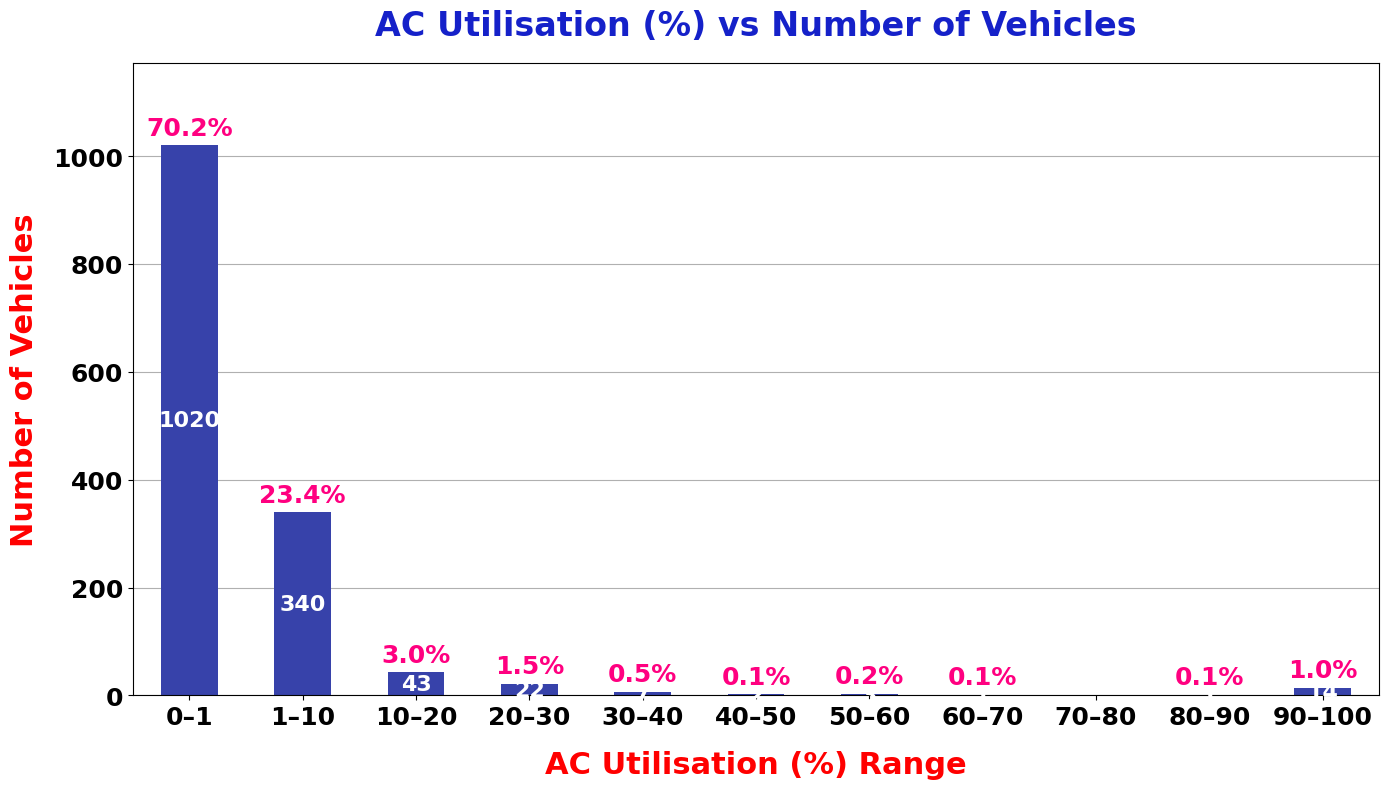

C:\Users\HTL_Sanmathi\AppData\Local\Temp\ipykernel_25176\1474506783.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['70-80', '60-70', '0-10', '90-100', '70-80', ..., '80-90', '70-80', '90-100', '80-90', '60-70']
Length: 1453
Categories (10, object): ['0-10' < '10-20' < '20-30' < '30-40' ... '60-70' < '70-80' < '80-90' < '90-100']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  df_plot.loc[:, 'bin'] = pd.cut(df_plot[metric], bins=bins, labels=labels, right=True, include_lowest=True)


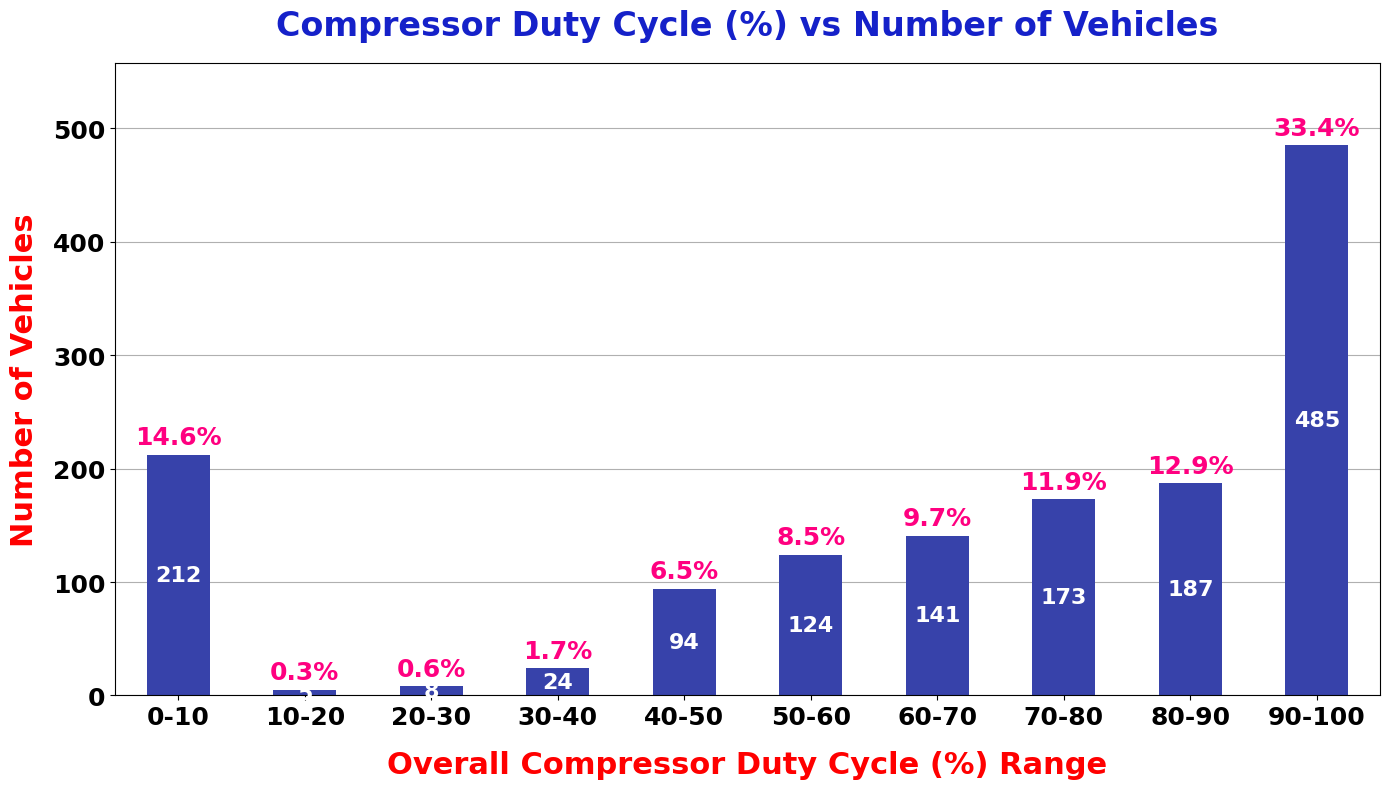

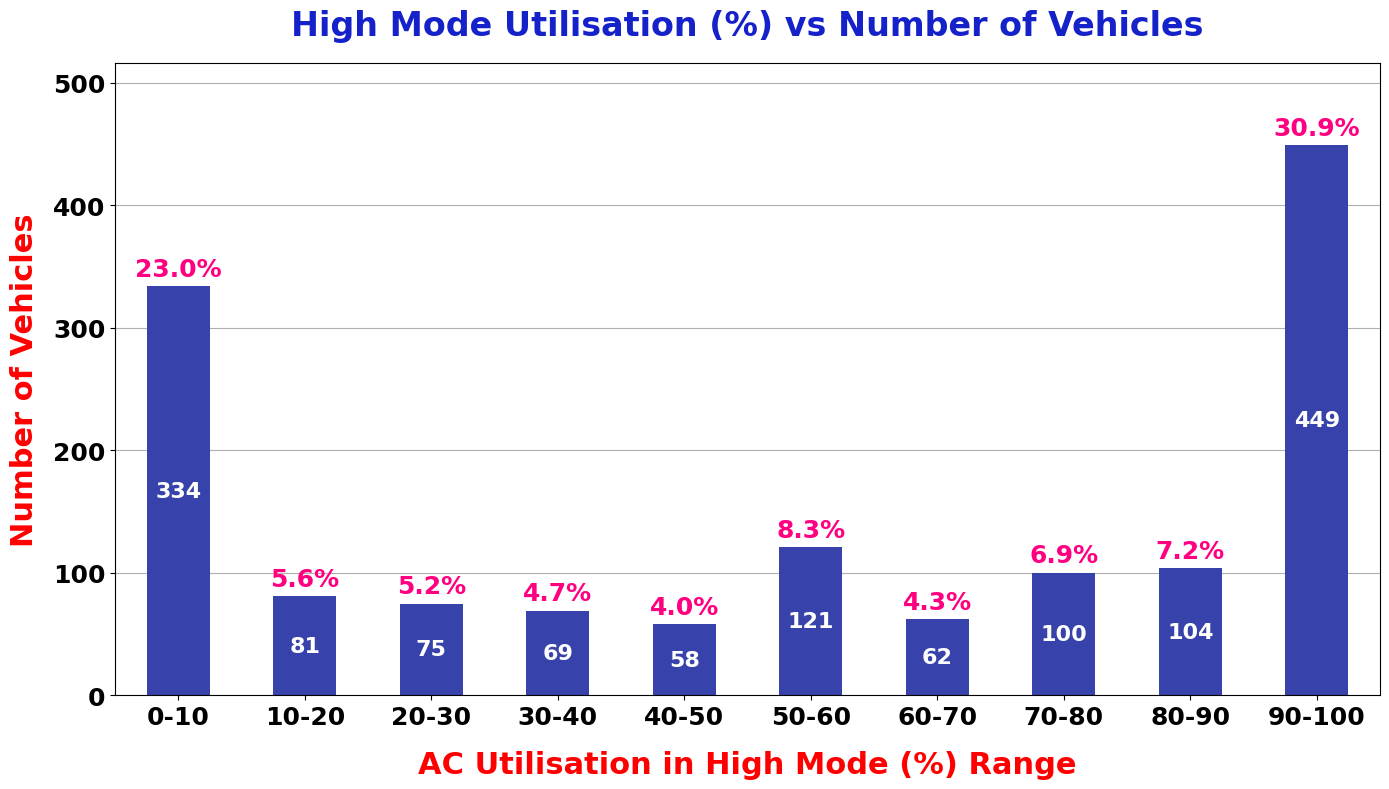

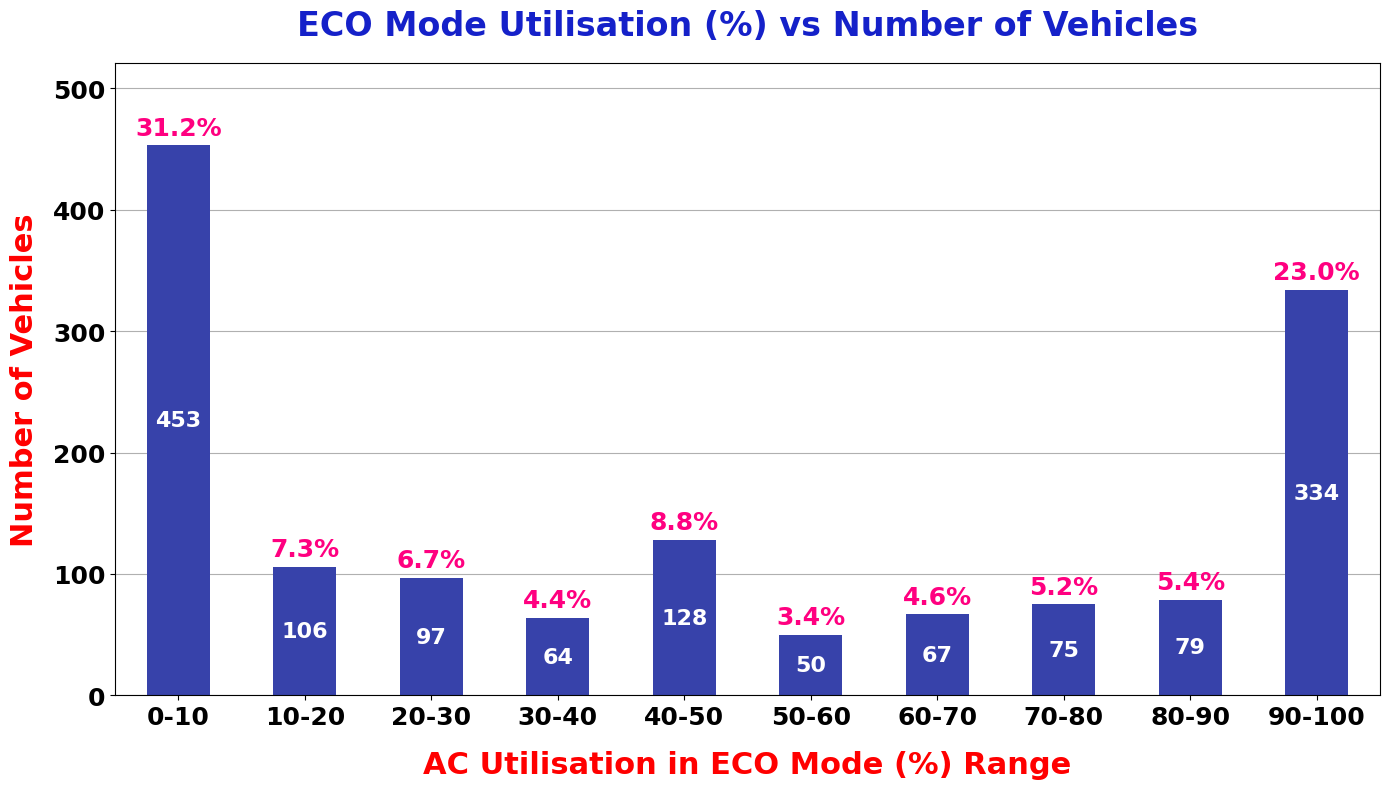

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# === Custom bin logic ===
def custom_bins(metric_name):
    if metric_name == 'AC Utilisation (%)':
        bins = [0, 1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
        labels = ['0–1', '1–10', '10–20', '20–30', '30–40', '40–50',
                  '50–60', '60–70', '70–80', '80–90', '90–100']
    else:
        bins = list(range(0, 110, 10))
        labels = [f"{i}-{i+10}" for i in bins[:-1]]
    return bins, labels

# === Step 1: Load summary file ===
# Note: Ensure this file path is correct on your system
summary_file = r"C:\Users\HTL_Sanmathi\Downloads\AC_Dec_G45_Summary\G45_Single_AC_Summarization\G45_DEC_AC_Summary_Generation.csv"
df = pd.read_csv(summary_file)

# === Step 3: Remove summary row from plotting data ===
df_plot = df[df['VIN'] != 'VIN_COUNT_SUMMARY'].copy()

# === Step 4: Define metrics and titles ===
metrics = {
    'AC Utilisation (%)': 'AC Utilisation (%) vs Number of Vehicles',
    'Overall Compressor Duty Cycle (%)': 'Compressor Duty Cycle (%) vs Number of Vehicles',
    'AC Utilisation in High Mode (%)': 'High Mode Utilisation (%) vs Number of Vehicles',
    'AC Utilisation in ECO Mode (%)': 'ECO Mode Utilisation (%) vs Number of Vehicles'
}

# === Step 6: Plot each metric ===
for metric, title in metrics.items():
    plt.figure(figsize=(14, 8))

    # Fill missing values safely
    df_plot.loc[:, metric] = df_plot[metric].fillna(0)

    # Apply bin logic
    bins, labels = custom_bins(metric)
    if len(labels) != len(bins) - 1:
        print(f"⚠️ Bin mismatch for {metric}: {len(bins)} bins, {len(labels)} labels")
        continue

    df_plot.loc[:, 'bin'] = pd.cut(df_plot[metric], bins=bins, labels=labels, right=True, include_lowest=True)

    # Count vehicles per bin
    bin_counts = df_plot['bin'].value_counts().sort_index()
    total = bin_counts.sum()

    # Plot bar chart with colors matching the image
    ax = bin_counts.plot(kind='bar', color="#3742aa", edgecolor="#ffffff", linewidth=0) # Removed edgecolor
    ax.set_axisbelow(True)

    # Calculate maximum y-value to set consistent axes limits
    max_y_value = bin_counts.max()

    # Add percentage above and count inside the bar
    for i, value in enumerate(bin_counts):
        if value > 0:
            percent = (value / total) * 100
            # Place percentage label just above the bar top edge
            ax.text(i, value + (max_y_value * 0.01), f"{percent:.1f}%", ha='center', va='bottom',
                    fontsize=18, fontweight='bold', color="#ff0080")
            # Place count label inside the bar
            ax.text(i, value / 2, str(value), ha='center', va='center',
                    fontsize=16, fontweight='bold', color="white")

    # Chart styling (matched colors to the image)
    plt.title(title, fontsize=24, fontweight='bold', color="#1521C9", pad=20)
    plt.xlabel(f'{metric} Range', fontsize=22, fontweight='bold', color='red', labelpad=15)
    plt.ylabel('Number of Vehicles', fontsize=22, fontweight='bold', color='red', labelpad=10)
    plt.xticks(rotation=0, fontsize=18, fontweight='bold')
    plt.yticks(fontsize=18, fontweight='bold')
    plt.grid(axis='y')

    # Adjust Y-axis limits slightly higher to accommodate top labels better
    ax.set_ylim(0, max_y_value * 1.15)

    plt.tight_layout()
    plt.show()


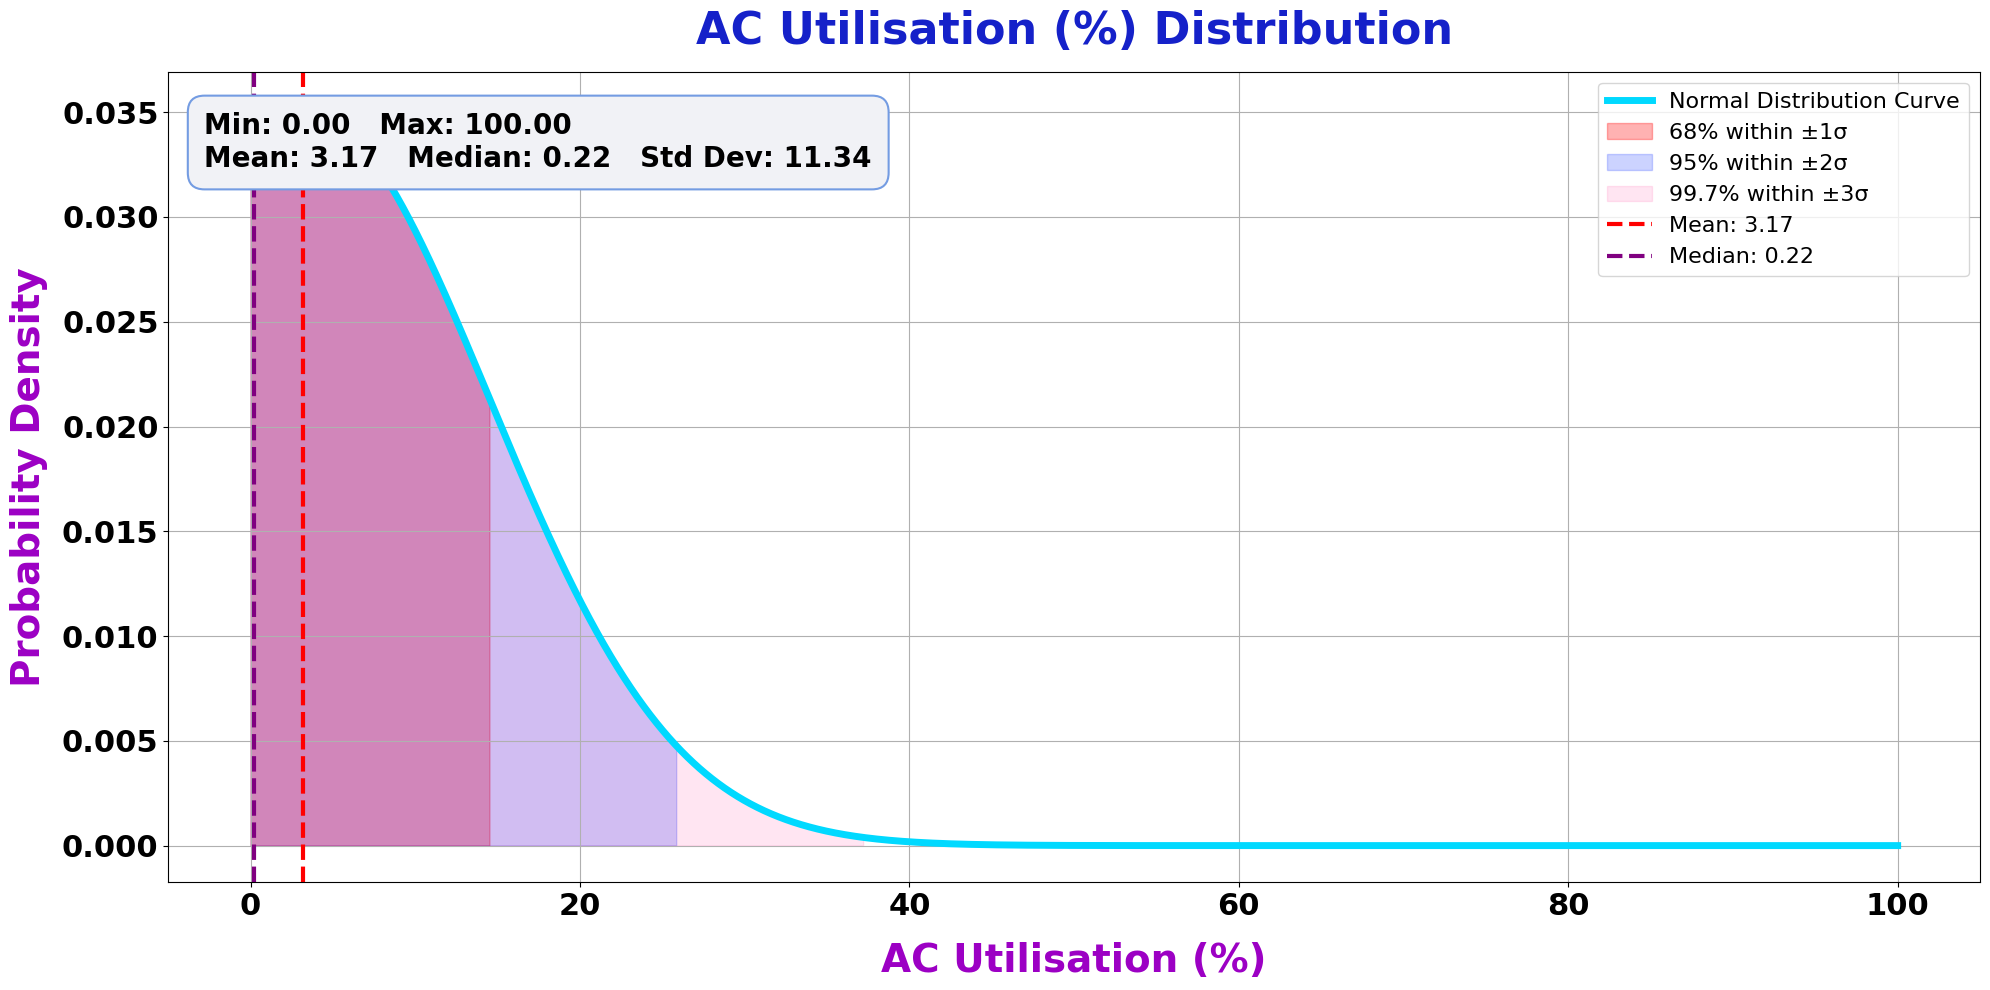

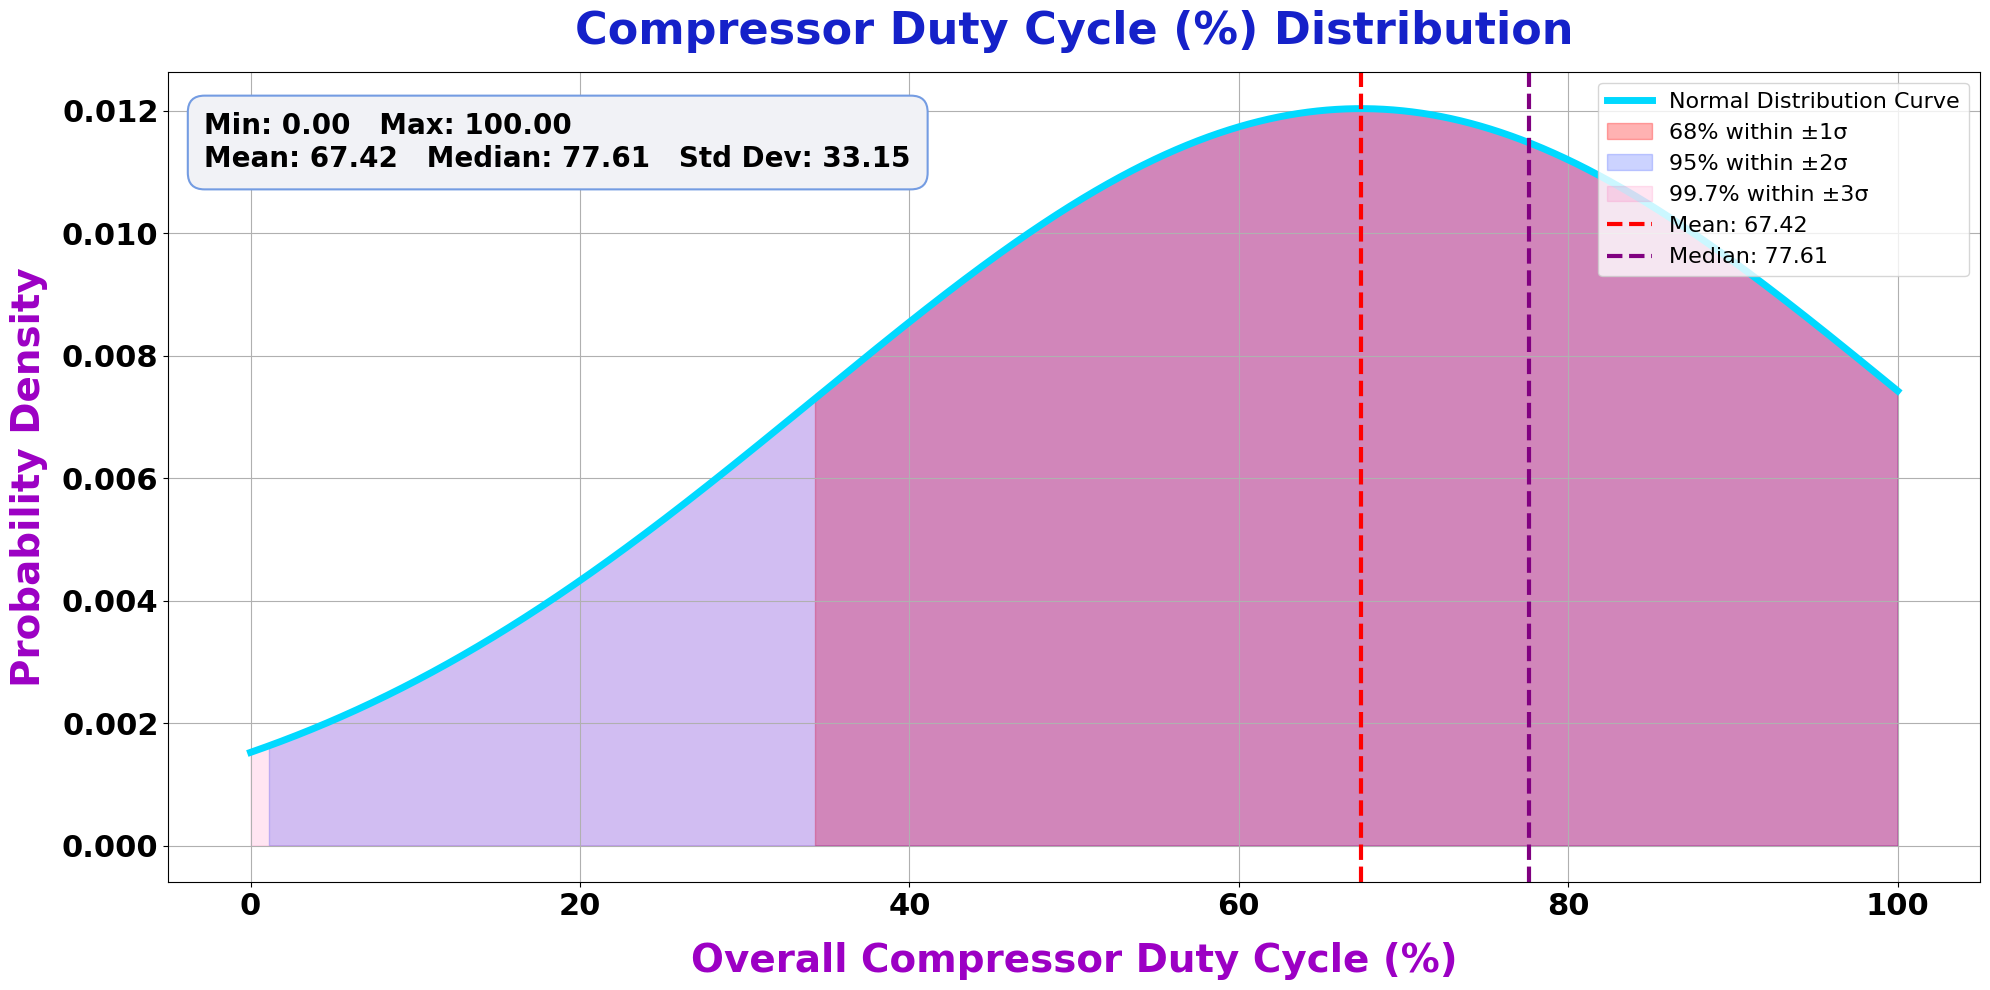

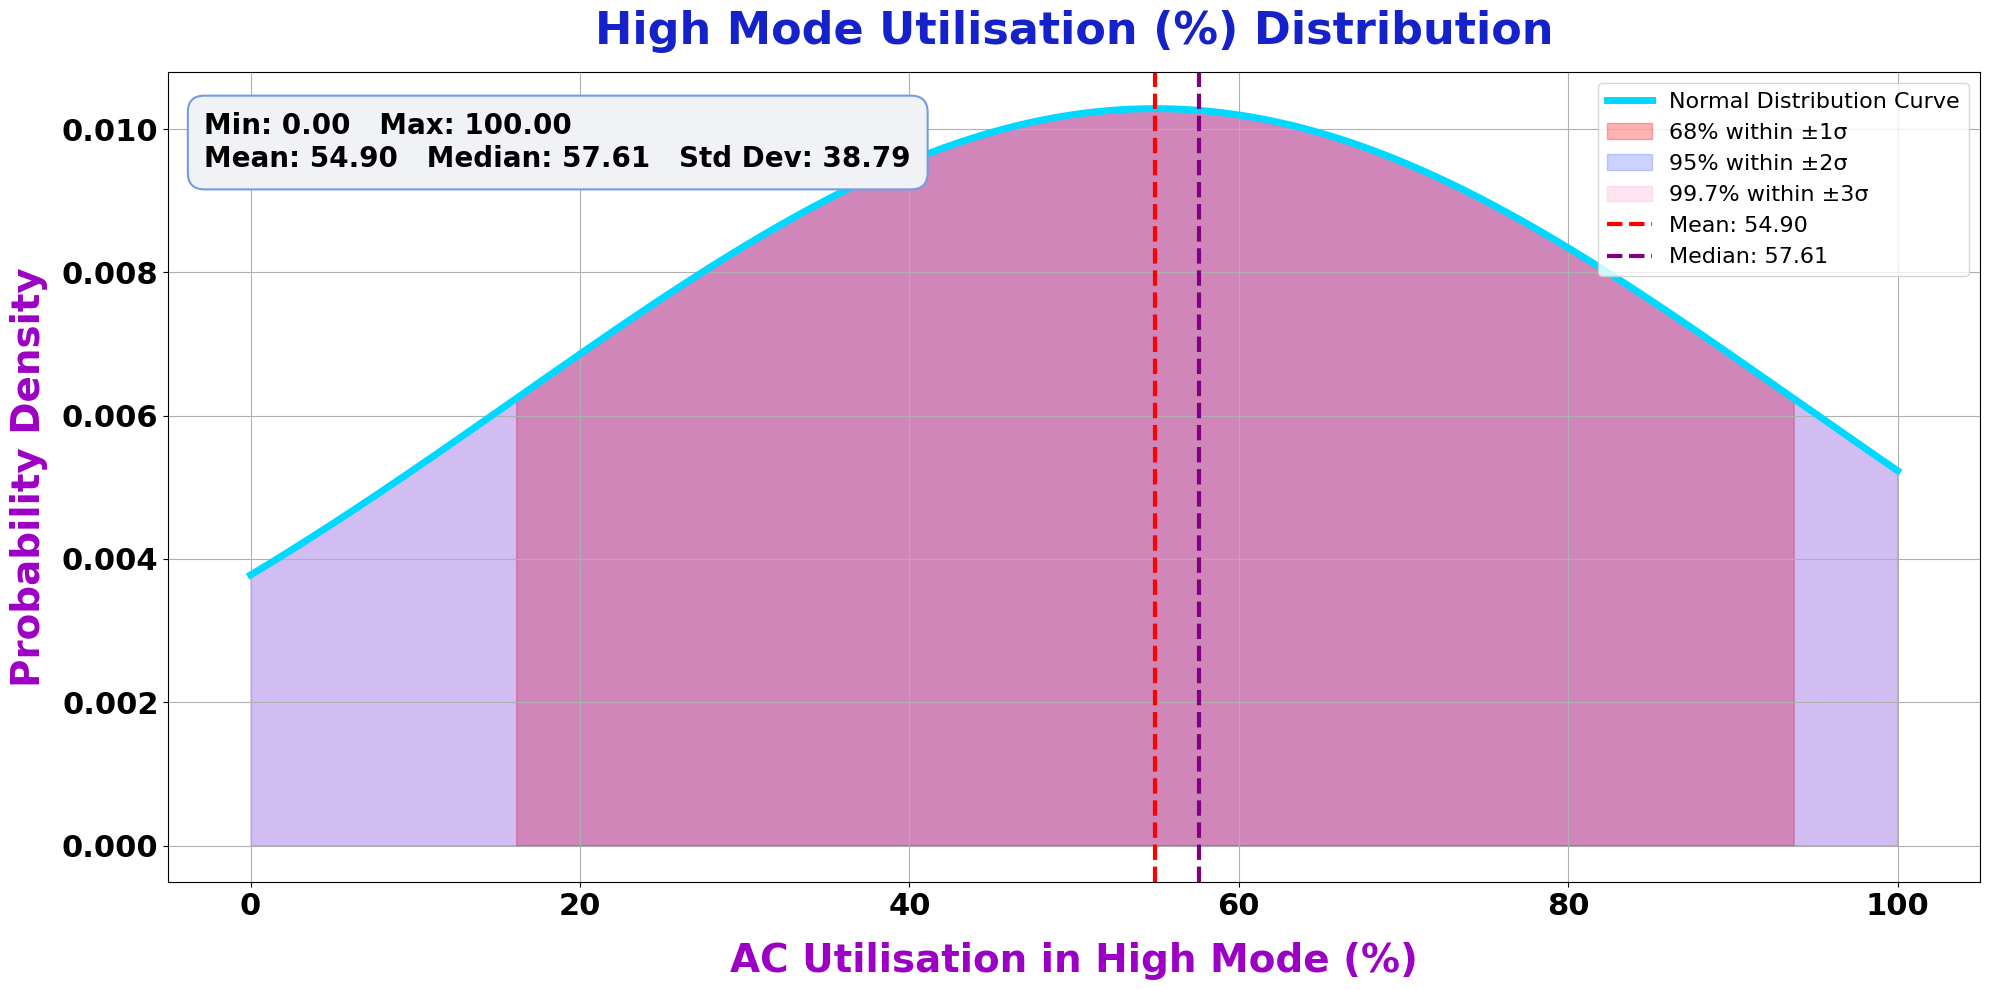

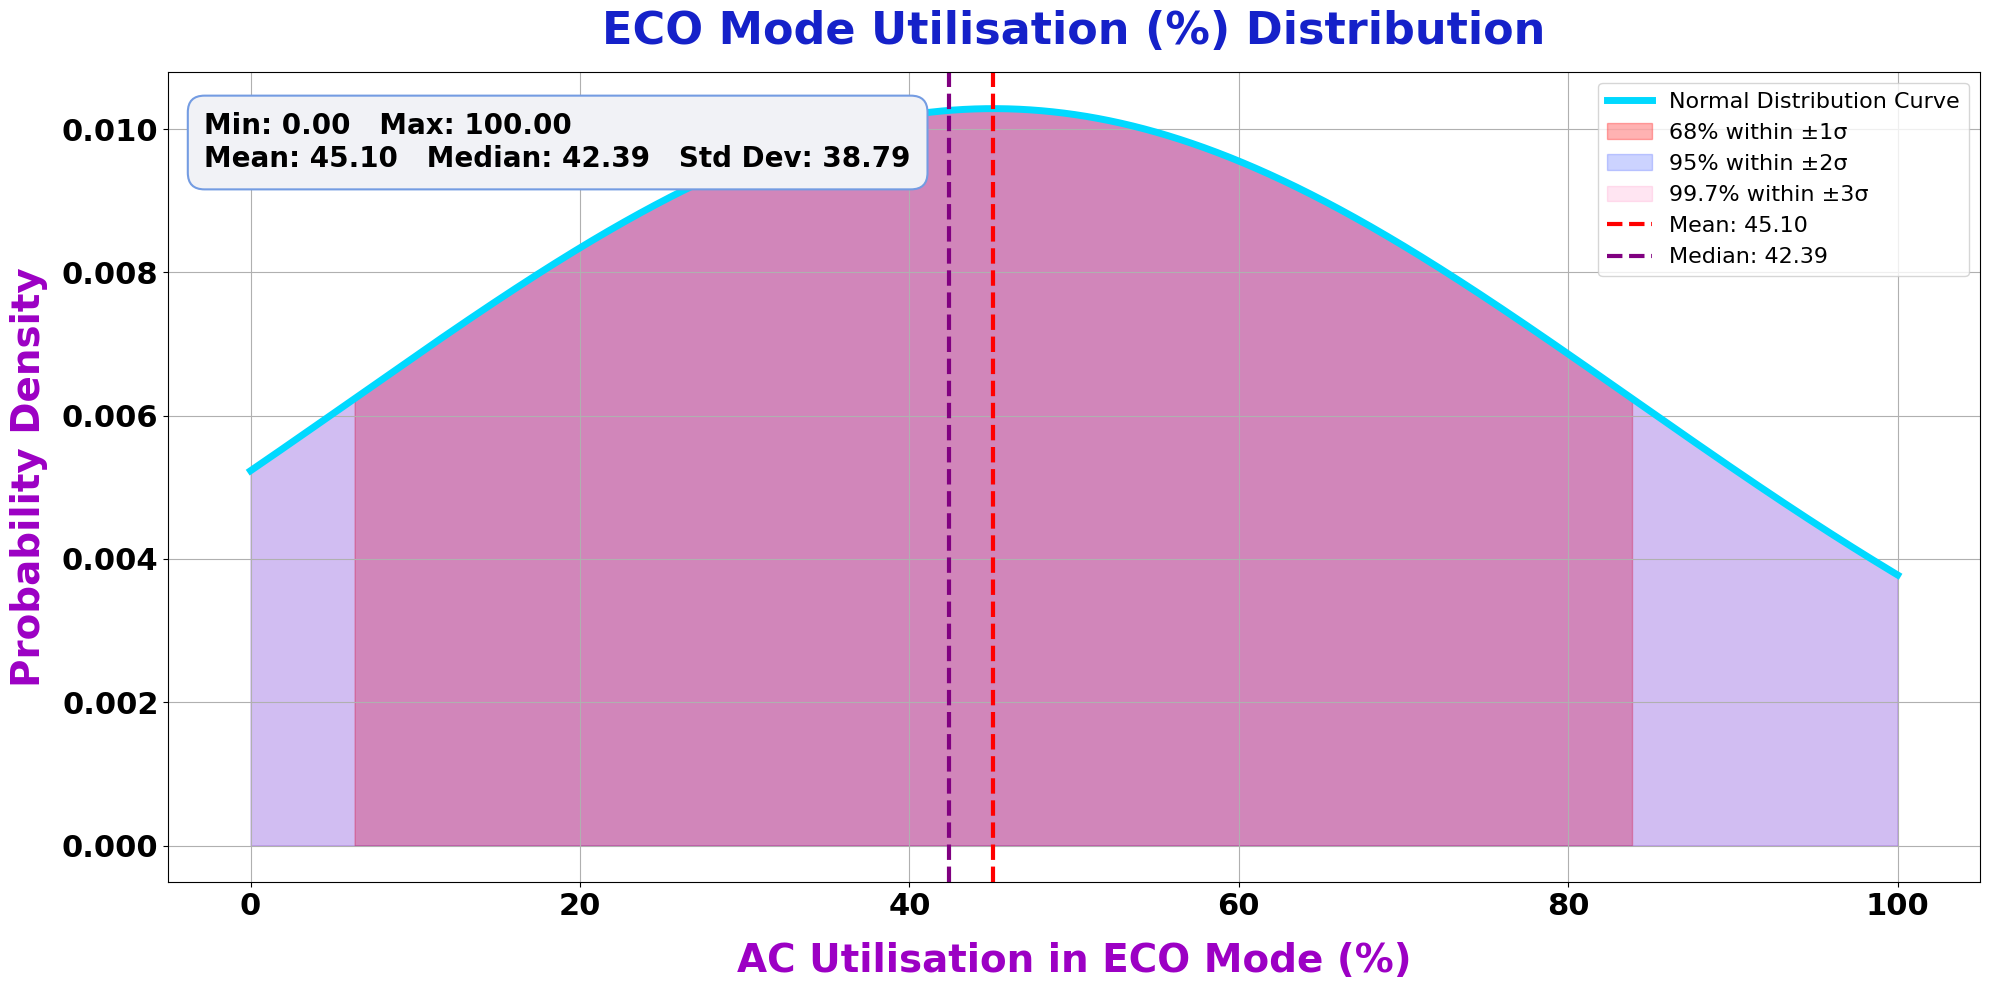

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import os

# === Step 1: Load summary file ===
summary_file = r"C:\Users\HTL_Sanmathi\Downloads\AC_Dec_G45_Summary\G45_Single_AC_Summarization\G45_DEC_AC_Summary_Generation.csv"
df = pd.read_csv(summary_file)

# Note: df_plot needs to be defined from the original df
# Assuming VIN_COUNT_SUMMARY row removal is required as in previous examples
df_plot = df[df['VIN'] != 'VIN_COUNT_SUMMARY'].copy()


# === Step 4: Define metrics and titles ===
metrics = {
    'AC Utilisation (%)': 'AC Utilisation (%) Distribution',
    'Overall Compressor Duty Cycle (%)': 'Compressor Duty Cycle (%) Distribution',
    'AC Utilisation in High Mode (%)': 'High Mode Utilisation (%) Distribution',
    'AC Utilisation in ECO Mode (%)': 'ECO Mode Utilisation (%) Distribution'
}

# === Step 5: Create output folder for charts ===
output_folder = r"C:\Users\HTL_Sanmathi\OneDrive - Ashok Leyland Ltd\Sanmathi S_Working Code\AC_Diagnostics\AC_Output\Charts"
os.makedirs(output_folder, exist_ok=True)

# === Step 6: Plot each metric with normal distribution overlay ===
for metric, title in metrics.items():
    plt.figure(figsize=(20, 10))
    ax = plt.gca() # Get current axis instance

    # Clean and extract data
    data = df_plot[metric].dropna()

    if data.empty:
        print(f"Skipping {metric} due to empty data after dropna.")
        plt.close()
        continue

    mean = np.mean(data)
    median = np.median(data)
    std = np.std(data)
    min_val = np.min(data)
    max_val = np.max(data)

    # Generate normal distribution curve
    x = np.linspace(min_val, max_val, 8000)
    pdf = norm.pdf(x, mean, std)

    # Plot normal distribution curve
    plt.plot(x, pdf, color="#00D9FF", linewidth=5, label='Normal Distribution Curve')

    # Empirical rule shading
    plt.fill_between(x, pdf, where=((x >= mean - std) & (x <= mean + std)),
                     color="#FF0000", alpha=0.3, label='68% within ±1σ')
    plt.fill_between(x, pdf, where=((x >= mean - 2 * std) & (x <= mean + 2 * std)),
                     color="#0026FF", alpha=0.2, label='95% within ±2σ')
    plt.fill_between(x, pdf, where=((x >= mean - 3 * std) & (x <= mean + 3 * std)),
                     color="#FF0080FF", alpha=0.1, label='99.7% within ±3σ')
    

    # Vertical lines for mean and median
    plt.axvline(mean, color='red', linestyle='--', linewidth=3, label=f'Mean: {mean:.2f}')
    plt.axvline(median, color='purple', linestyle='--', linewidth=3, label=f'Median: {median:.2f}')

    # Styled label box on the LEFT side (INCREASED FONTSIZE TO 20)
    stats_text = (
        f"Min: {min_val:.2f}   Max: {max_val:.2f}\n"
        f"Mean: {mean:.2f}   Median: {median:.2f}   Std Dev: {std:.2f}"
    )
    plt.text(
        0.02, 0.95, stats_text,
        transform=ax.transAxes,
        fontsize=20, # Increased from 16
        fontweight='bold',
        color="#000000",
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(
            boxstyle='round,pad=0.6',
            facecolor="#f1f2f6",
            edgecolor="#749ce2",
            linewidth=1.5
        )
    )

    # Final chart styling (Increased title/label/tick font sizes)
    plt.title(title, fontsize=32, fontweight='bold', color="#1521C9", pad=20) # Increased from 28
    plt.xlabel(f'{metric}', fontsize=28, fontweight='bold', color="#9C00C4", labelpad=15) # Increased from 24
    plt.ylabel('Probability Density', fontsize=28, fontweight='bold', color="#9C00C4", labelpad=10) # Increased from 24
    plt.grid(True)
    
    # Tick parameters (Increased from 20)
    plt.xticks(rotation=0, fontsize=22, fontweight='bold')
    plt.yticks(fontsize=22, fontweight='bold')
    
    # Legend (Increased fontsize to 16)
    plt.legend(loc='upper right', fontsize=16) # Increased from 14

    plt.tight_layout()
    plt.show()
